<center><span style="font-size:60px;"><b>EVALUATION METRICS</b></span></center>

In [1]:
# IMPORTS
import os
import math
import glob
from PIL import Image
import matplotlib.pyplot as plt


import torch
import torchvision.transforms as T
from torchmetrics.functional import structural_similarity_index_measure as ssim_fn   # pip install torchmetrics
import lpips   # pip install lpips

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


We apply metrics to both whole image and hole-only patch. This is because with hole-only we evaluate the generated patch excluding the sorrounding frame (which is basically copied from grounf truth) while with the whole image we evaluate also the global consistency of the resulting image.

---

---

---

<center><span style="font-size:40px;"><b>METRICS FUNCTIONS</b></span></center>

# L1

Both L1 error and PSNR are, at their core, ways of measuring how far a reconstructed image is from a ground-truth image.

Let’s start from L1. Suppose you have an original image $I$ and a predicted image $\hat{I}$. The L1 error is then just the average absolute difference between these two functions over all pixels:

$$
L1 = \frac{1}{N} \sum_{i=1}^{N} |I_i - \hat{I}_i|.
$$

Here $N$ is the total number of pixels. So at each pixel, it measures how wrong you are in magnitude, and then it averages everything.

This simplicity is both its strength and its weakness. On the positive side, L1 is extremely stable and easy to interpret: if your L1 decreases, your prediction is, in an average absolute sense, closer to the ground truth. 

However, its main limitation in image generation tasks is more fundamental: it assumes that the ground truth is the only correct answer. In inpainting, this assumption is not really valid. If your model fills a missing region with a visually plausible texture that differs from the original image, L1 will still penalize it linearly, even if the result looks realistic to a human observer. This is why optimizing L1 often leads to “average-looking” or slightly blurred outputs.

In [2]:
# ----------------------------
# 1. L1 METRIC
# ----------------------------

def compute_L1(img_pred, img_gt, mask=None):
    """
    Computes L1 error between predicted and ground-truth image.

    Args:
        img_pred, img_gt: tensors of shape (C, H, W), values in [0,1]
        mask (optional): tensor of shape (1, H, W) or (C, H, W)
                         1 = region to evaluate (hole)
                         0 = ignore

    Returns:    scalar L1 error    (lower the better)
    """

    # absolute pixel-wise difference
    diff = torch.abs(img_pred - img_gt)

    # if a mask is given, we compute L1 on whole image (see return line), otherwise L1 on generated area
    if mask is not None:
        
        # ensure mask has same number of channels (broadcast if needed)
        if mask.shape[0] == 1:
            mask = mask.expand_as(diff)

        diff = diff * mask          # apply mask (keep only hole region)
        valid_pixels = mask.sum()   # number of valid pixels (per channel)
        return diff.sum() / (valid_pixels + 1e-8)   # avoid division by zero (e.g. empty mask)

    # full-image L1
    return diff.mean()
    

# PSNR

PSNR starts from a different perspective, instead of directly reporting the average error, it first computes the mean squared error:

$$
MSE = \frac{1}{N} \sum_{i=1}^{N} (I_i - \hat{I}_i)^2,
$$

and then transforms it into a logarithmic scale:

$$
PSNR = 10 \log_{10}\left(\frac{MAX^2}{MSE}\right).
$$

Here $MAX$ is the maximum possible pixel value (for example 255 for 8-bit images, or 1 if normalized). The intuition behind PSNR comes from signal processing: you can think of the image as a signal, and the reconstruction error as noise corrupting that signal. The ratio is therefore a signal-to-noise ratio, and the logarithm simply compresses this into a more manageable numerical range, measured in decibels.

Because PSNR is based on squared error, it behaves similarly to L2 loss in terms of its geometric bias: large errors are penalized disproportionately more than small ones. This means PSNR is even more sensitive to outliers than L1. A few badly reconstructed pixels in a region can significantly reduce the score. Like L1, it is also purely pixel-based, so it does not understand perceptual similarity. Two images that look nearly identical to a human can still have a relatively low PSNR if they differ slightly in pixel values, especially in textured regions.


L1 and PSNR both assume that the ground truth image is the unique correct target, which is not true for image inpainting. This is why modern papers increasingly complement them with perceptual or distribution-based metrics, because pixel-wise distances alone cannot capture whether a completed region looks semantically and visually plausible.


In [3]:
# ----------------------------
# 2. PSNR METRIC
# ----------------------------

def compute_psnr(img_pred, img_gt, mask=None, eps=1e-8):
    """
    Computes PSNR (Peak Signal-to-Noise Ratio) in dB.

    Formula:
        PSNR = 10 * log10(1 / MSE)       (because images are in [0,1], so MAX=1)

    Args:
        img_pred, img_gt: (C, H, W) in [0,1]
        mask (optional): evaluate only masked region

    Returns:   scalar PSNR (higher = better)
    """

    # squared error
    mse_map = (img_pred - img_gt) ** 2

    # if a mask is not given, we compute PSNR only in the generated area ...
    if mask is not None:
        
        # match channels if needed
        if mask.shape[0] == 1:
            mask = mask.expand_as(mse_map)

        mse_map = mse_map * mask      # apply mask (keep only hole region)
        valid_pixels = mask.sum()     # number of valid pixels (per channel)
        mse = mse_map.sum() / (valid_pixels + eps)   # compute mean

    # ... otherwise on whole image
    else:
        mse = mse_map.mean()

    # convert to PSNR
    psnr = 10 * torch.log10(1.0 / (mse + eps))   # avoid division by zero (e.g. empty mask)

    return psnr.item()
    

# SSIM

SSIM (Structural Similarity Index) is a metric designed to measure image similarity in a way that is closer to human visual perception than simple pixel-wise errors such as L1 or MSE. Instead of comparing images point-by-point, SSIM compares them in terms of **structure**.

Mathematically, SSIM is defined between two image patches $x$ and $y$ as

$$
SSIM(x,y) = \frac{(2\mu_x \mu_y + C_1)(2\sigma_{xy} + C_2)}{(\mu_x^2 + \mu_y^2 + C_1)(\sigma_x^2 + \sigma_y^2 + C_2)}
$$

where:

* $\mu_x, \mu_y$ are the mean intensities of the two patches,
* $\sigma_x^2, \sigma_y^2$ are the variances (contrast information),
* $\sigma_{xy}$ is the covariance between $x$ and $y$ (structural similarity),
* $C_1, C_2$ are small constants used to stabilize the division when denominators are close to zero.

We can decompose SSIM into three perceptual components:

1. **Luminance comparison**: This measures whether the two patches have similar overall brightness.

$$
l(x,y) = \frac{2\mu_x \mu_y + C_1}{\mu_x^2 + \mu_y^2 + C_1}
$$

2. **Contrast comparison**: This measures whether the intensity variations (contrast) are similar.

$$
c(x,y) = \frac{2\sigma_x \sigma_y + C_2}{\sigma_x^2 + \sigma_y^2 + C_2}
$$

3. **Structure comparison**: This measures whether the spatial patterns of intensity changes are aligned (edges, textures, geometry).

$$
s(x,y) = \frac{\sigma_{xy} + C_3}{\sigma_x \sigma_y + C_3}
$$



SSIM combines these ideas (with a common simplified form merging contrast and structure) into a single score that ranges approximately in $[-1,1]$, where $1$ indicates perfect similarity.

Conceptually, SSIM assumes that the human visual system is more sensitive to **changes in structure** than to absolute pixel differences. For example, a slight shift in brightness across an image is often less important than destroying an edge or texture pattern. This is why SSIM tends to correlate better with perceptual quality than L1 or PSNR.

In practice, SSIM is computed locally: the image is divided into small windows (for example $11 \times 11$ patches), SSIM is computed for each window, and the final score is obtained by averaging over all patches. This makes SSIM sensitive to local distortions rather than only global statistics.

SSIM also has important **limitations**:
* it still relies on a reference image, so it is not suitable when multiple valid outputs exist (as in inpainting or image generation)
* it is fundamentally a local statistical measure and does not understand high-level semantics: two images with very different objects but similar textures may still obtain a relatively high SSIM.
* it can still favor overly smooth reconstructions, especially when structural alignment is preserved but fine details are missing
* SSIM is sensitive to small spatial misalignments; even a slight shift can significantly reduce the score, even if the images are perceptually very similar

In [4]:
# ----------------------------
# 3. SSIM METRIC
# ----------------------------

def compute_ssim(img_pred, img_gt, ssim_fn):
    """
    Computes SSIM on FULL IMAGE.

    Args:
        img_pred, img_gt: tensors (C, H, W) in [0,1]
        ssim_fn: torchmetrics SSIM function

    Returns:     scalar SSIM (higher = better, max = 1)
    """

    # add batch dimension: (1, C, H, W)
    img_pred = img_pred.unsqueeze(0)
    img_gt = img_gt.unsqueeze(0)

    # ensure same device as metric
    img_pred = img_pred.to(device)
    img_gt = img_gt.to(device)

    # compute SSIM
    ssim_val = ssim_fn(img_pred, img_gt, data_range=1.0)
    # the data_range=1.0 parameter specifies that pixel values are normalized between 0.0 and 1.0

    return ssim_val.item()

# LPIPS

**LPIPS (Learned Perceptual Image Patch Similarity)** is a perceptual metric designed to measure how *visually similar* two images appear to humans, rather than how close they are pixel-by-pixel. The key idea is that deep neural networks trained for vision tasks (e.g., classification) learn feature representations that align well with human perception; LPIPS leverages these representations to compare images.

Instead of comparing images directly in pixel space, LPIPS compares them in the **feature space of a pretrained convolutional network** (such as VGG or AlexNet). Given two images $x$ and $x_0$, both are passed through the same network, producing feature maps at several layers. These feature maps encode progressively higher-level information: early layers capture edges and textures, while deeper layers capture shapes and semantic content. LPIPS measures the distance between these representations, layer by layer, producing a similarity score that better reflects perceptual differences. Thus, two images that are pixel-wise different but perceptually similar (e.g., slightly shifted textures) will have a low LPIPS distance, unlike with L1 or PSNR.

Let $\phi_l(x)$ denote the activation (feature map) of layer $l$ for image $x$. LPIPS first normalizes these features channel-wise to unit length, obtaining $\hat{\phi}_l(x)$. The distance between two images is then computed as a weighted sum of squared differences across layers and spatial locations:

$$
\text{LPIPS}(x, x_0) = \sum_l w_l \cdot \frac{1}{H_l W_l} \sum_{h,w} \| \hat{\phi}_l(x)_{h,w} - \hat{\phi}_l(x_0)_{h,w} \|_2^2
$$

where:

* $l$ indexes the selected layers,
* $H_l, W_l$ are spatial dimensions of the feature map,
* $w_l$ are learned scalar weights (trained to match human perceptual judgments).

These weights are obtained by calibrating the metric on datasets of human similarity judgments, making LPIPS *learned* rather than purely hand-crafted.

Low LPIPS → perceptually similar\
High LPIPS → perceptually different

### Strengths and limitations

Unlike L1 or PSNR, it does not penalize plausible variations too harshly, and it can distinguish between blurry reconstructions and sharp, realistic ones. Another advantage is that it operates at multiple feature levels, combining low-level and high-level information.

Despite its strengths, LPIPS is not perfect:
* it still depends on a **pretrained network**, so its behavior is biased by the training data and architecture (e.g., ImageNet-trained models)
* it is not a true semantic metric: it may consider two images similar even if they differ in important high-level meaning (or vice versa)
* requires a **reference ground truth image**, so it cannot evaluate realism alone (unlike FID).
* it is computationally heavier than simple metrics like L1 or PSNR, since it requires a forward pass through a deep network.

In [5]:
# ----------------------------
# 4. LPIPS METRIC (PERCEPTUAL)
# ----------------------------

# initialize once (IMPORTANT: expensive model)
lpips_model = lpips.LPIPS(net='alex').to(device)
lpips_model.eval()


def compute_lpips(img_pred, img_gt):
    """
    Computes LPIPS (perceptual similarity) on FULL IMAGE.

    Args:        img_pred, img_gt: tensors (C, H, W) in [0,1]

    Returns:     scalar LPIPS distance (lower = better)
    """

    # add batch dimension + move to device
    img_pred = img_pred.unsqueeze(0).to(device)
    img_gt = img_gt.unsqueeze(0).to(device)

    # LPIPS expects input in [-1, 1]
    img_pred = img_pred * 2.0 - 1.0
    img_gt = img_gt * 2.0 - 1.0

    # no gradients needed
    with torch.no_grad():
        dist = lpips_model(img_pred, img_gt)

    return dist.item()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/benedetto/anaconda3/envs/vision_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/benedetto/anaconda3/envs/vision_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /home/benedetto/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|█████████████████████████████████████████████████████████████████████████████████████| 233M/233M [00:25<00:00, 9.68MB/s]


Loading model from: /home/benedetto/anaconda3/envs/vision_env/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


# (FID metric, eventually)

---

---

---

<center><span style="font-size:40px;"><b>LOADING AND EVALUATING FUNCTIONS</b></span></center>

Mask convention matters a lot
* 1 = missing region
* 0 = known region

Dimensions format:
* image format on disk / PIL / OpenCV: (H, W, C)
* pytorch format: (C, H, W)

`T.ToTensor()` performs 3 operations automatically: 
* converts HWC in CHW
* converts uint8 in float32
* Normalizes values: pixel / 255 so from 0–255 to 0.0–1.0

In [40]:
# ----------------------------
# 1. IMAGE LOADING UTILITIES
# ----------------------------

def load_image(path):
    """
    Loads an RGB image and converts it to a torch tensor in [0,1].

    Args:      path: path to image file
    Returns:   tensor of shape (C, H, W), values in [0,1]
    """
    img = Image.open(path).convert("RGB")  # for now, image is HWC format with [0-255] values

    # ToTensor:
    # - converts to float
    # - scales [0,255] → [0,1]
    transform = T.ToTensor()    # now, image is CHW format with [0.-1.] values

    return transform(img)


def load_mask(path):
    """
    Loads a mask and converts it to a binary tensor in [0,1].

    Args:      path: path to mask image
    Returns:   tensor of shape (1, H, W) with values {0,1}
    """
    mask = Image.open(path).convert("L")  # grayscale
    mask = T.ToTensor()(mask)

    # binarize (important if mask is not perfectly 0/255)
    mask = (mask > 0.5).float()

    return mask

def _check_range(img, name="image"):
    if img.max() > 1.0 or img.min() < 0.0:
        raise ValueError(f"{name} values should be in [0,1], got range [{img.min()}, {img.max()}]")


# ----------------------------
# 2. SINGLE IMAGE EVALUATION
# ----------------------------

def evaluate_pair(pred, gt, mask=None, metrics=("L1", "PSNR", "SSIM", "LPIPS"), ssim_fn=None):
    """
    Evaluates a single (prediction, ground truth) pair.

    Args:
        pred, gt: tensors (C, H, W) in [0,1]
        mask: optional mask (1,H,W)
        metrics: tuple/list specifying which metrics to compute e.g. ("L1", "PSNR") or ("SSIM", "LPIPS")
        ssim_fn: required if "SSIM" is in metrics

    Returns:   dictionary with selected metrics

    Note: this function is written to work inside the evaluate_folders function.
          If you want to use it directly on an image/mask to test the code, you must first use the load functions
    """

    results = {}

    # check:
    _check_range(pred, "pred")
    _check_range(gt, "gt")
    # if pred.max() > 1:  pred = pred / 255.0

    # --- Pixel-wise metrics (optionally masked) ---
    if "L1" in metrics:     results["L1"] = float(compute_L1(pred, gt, mask))
    if "PSNR" in metrics:   results["PSNR"] = float(compute_psnr(pred, gt, mask))

    # --- Perceptual / structural metrics (full image) ---
    if "SSIM" in metrics:
        if ssim_fn is None:  raise ValueError("SSIM requested but ssim_fn is None")
        results["SSIM"] = float(compute_ssim(pred, gt, ssim_fn))

    if "LPIPS" in metrics:
        results["LPIPS"] = float(compute_lpips(pred, gt))

    return results


# ----------------------------
# 3. FOLDER EVALUATION
# ----------------------------

def evaluate_folders(
    pred_dir,
    gt_dir,
    mask_dir=None,
    metrics=("L1", "PSNR", "SSIM", "LPIPS"),
    ssim_fn=None
):
    """
    Evaluates an entire dataset of images from their folders.

    Assumptions:
        - Files are aligned by alphabetical order
        - Same number of images in pred and gt folders
        - If mask_dir is provided → same number of masks

    Args:
        pred_dir: folder with predicted (inpainted) images
        gt_dir: folder with ground-truth images
        mask_dir: (optional) folder with masks
        metrics: list/tuple of metrics to compute
        ssim_fn: required if SSIM is used

    Returns:
        dictionary with average metrics over dataset
    """

    # get sorted file lists
    pred_paths = sorted(glob.glob(os.path.join(pred_dir, "*")))
    gt_paths = sorted(glob.glob(os.path.join(gt_dir, "*")))

    # sanity check
    if len(pred_paths) != len(gt_paths):
        raise ValueError("Prediction and GT folders have different sizes")

    # mask handling
    use_mask = mask_dir is not None
    if use_mask:
        mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*")))

        if len(mask_paths) != len(pred_paths):
            raise ValueError("Mask folder size mismatch")

    # initialize accumulators dynamically
    totals = {m: 0.0 for m in metrics}
    n = len(pred_paths)   # number of images

    # ----------------------------
    # MAIN LOOP
    # ----------------------------
    for i in range(n):   # cycle over all images
        # load images
        pred = load_image(pred_paths[i])
        gt = load_image(gt_paths[i])
        mask = load_mask(mask_paths[i]) if use_mask else None   # load mask if available

        # compute selected metrics
        results = evaluate_pair(
            pred,
            gt,
            mask=mask,
            metrics=metrics,
            ssim_fn=ssim_fn
        )

        # accumulate results
        for k in results:
            totals[k] += results[k]

    # AVERAGE OVER DATASET
    avg_metrics = {k: totals[k] / n for k in totals}

    return avg_metrics
    

----

----

----

<center><span style="font-size:40px;"><b>RUNNING PIPELINE</b></span></center>

## TESTING THE CODE

In [39]:
# function used to plot the loaded image (so to verify they are loaded correctly)
def show_image(tensor, title="image"):
    """
    tensor: (C, H, W)
    """
    img = tensor.permute(1, 2, 0).cpu().numpy()  # CHW → HWC

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

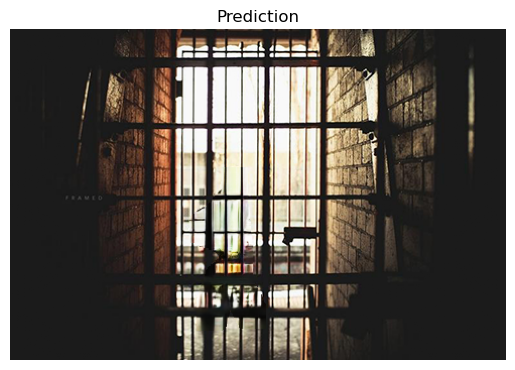

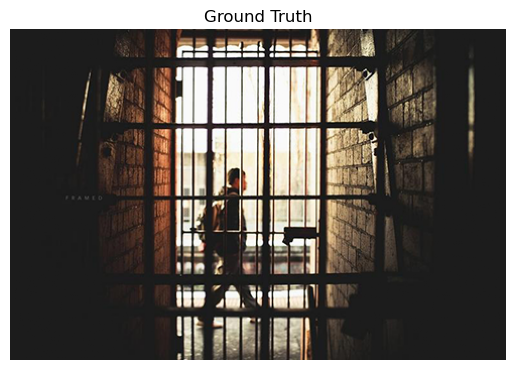

In [60]:
pred = load_image("./test_images/out.png")
gt = load_image("./test_images/example.png")
mask = load_mask("./test_images/example_mask.png")

show_image(pred, "Prediction")
show_image(gt, "Ground Truth")

In [61]:
# print(pred.min(), pred.max())
# print(gt.min(), gt.max())
# print(mask.min(), mask.max())
# pred[0,0]

In [62]:
metrics = evaluate_pair(pred, gt, mask, metrics=("L1", "PSNR", "SSIM", "LPIPS"), ssim_fn=ssim_fn)

In [63]:
metrics

{'L1': 0.2753097116947174,
 'PSNR': 7.995573043823242,
 'SSIM': 0.965300440788269,
 'LPIPS': 0.029262004420161247}

---

## EVALUATION PIPELINE

In [ ]:
pred_dir = 
gt_dir = 
mask_path = 

evaluate_folders(
    pred_dir,
    gt_dir,
    mask_dir=mask_path,
    metrics=("L1", "PSNR", "SSIM", "LPIPS"),
    ssim_fn=ssim_fn
)